In [200]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

Import Dataset

In [201]:
dataset = pd.read_csv('C:/Users/user/OneDrive/Documents/Learn AI/ML_Projects/medical-insurance-cost-prediction/dataset/medical_insurance_dataset_10k_enhanced.csv')

In [202]:
dataset.shape

(10000, 12)

In [203]:
dataset.head()

,age,sex,bmi,children,smoker,blood_pressure,cholesterol,glucose,heart_rate,exercise_level,alcohol_intake,charges_usd
0,56,male,29.5,3,no,159,283,94,71,medium,none,17741.51
1,46,male,30.5,0,no,140,203,160,93,low,none,14034.06
2,32,female,28.7,4,yes,114,281,141,95,low,moderate,38953.42
3,60,female,31.6,1,no,112,228,125,67,high,high,15515.48
4,25,female,24.6,4,no,139,185,151,68,medium,high,13461.26


Data Preproccesing

In [204]:
dataset.isnull().sum()

age               0
sex               0
bmi               0
children          0
smoker            0
blood_pressure    0
cholesterol       0
glucose           0
heart_rate        0
exercise_level    0
alcohol_intake    0
charges_usd       0
dtype: int64

In [205]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   sex             10000 non-null  object 
 2   bmi             10000 non-null  float64
 3   children        10000 non-null  int64  
 4   smoker          10000 non-null  object 
 5   blood_pressure  10000 non-null  int64  
 6   cholesterol     10000 non-null  int64  
 7   glucose         10000 non-null  int64  
 8   heart_rate      10000 non-null  int64  
 9   exercise_level  10000 non-null  object 
 10  alcohol_intake  10000 non-null  object 
 11  charges_usd     10000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 937.6+ KB


In [206]:
dataset.value_counts('sex')

sex
male      5002
female    4998
Name: count, dtype: int64

In [207]:
dataset.value_counts('smoker')

smoker
no     7984
yes    2016
Name: count, dtype: int64

In [208]:
dataset = pd.get_dummies(dataset, drop_first=True,dtype=int)

In [209]:
#dataset = pd.get_dummies(dataset, columns = ['smoker'],dtype=int)

In [210]:
#dataset = pd.get_dummies(dataset, columns = ['sex'],dtype=int)

In [211]:
dataset.head()

,age,bmi,children,blood_pressure,cholesterol,glucose,heart_rate,charges_usd,sex_male,smoker_yes,exercise_level_low,exercise_level_medium,alcohol_intake_moderate,alcohol_intake_none
0,56,29.5,3,159,283,94,71,17741.51,1,0,0,1,0,1
1,46,30.5,0,140,203,160,93,14034.06,1,0,1,0,0,1
2,32,28.7,4,114,281,141,95,38953.42,0,1,1,0,1,0
3,60,31.6,1,112,228,125,67,15515.48,0,0,0,0,0,0
4,25,24.6,4,139,185,151,68,13461.26,0,0,0,1,0,0


In [212]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      10000 non-null  int64  
 1   bmi                      10000 non-null  float64
 2   children                 10000 non-null  int64  
 3   blood_pressure           10000 non-null  int64  
 4   cholesterol              10000 non-null  int64  
 5   glucose                  10000 non-null  int64  
 6   heart_rate               10000 non-null  int64  
 7   charges_usd              10000 non-null  float64
 8   sex_male                 10000 non-null  int64  
 9   smoker_yes               10000 non-null  int64  
 10  exercise_level_low       10000 non-null  int64  
 11  exercise_level_medium    10000 non-null  int64  
 12  alcohol_intake_moderate  10000 non-null  int64  
 13  alcohol_intake_none      10000 non-null  int64  
dtypes: float64(2), int64(12

In [213]:
num_cols = [
    "age",
    "bmi",
    "children",
    "blood_pressure",
    "cholesterol",
    "glucose",
    "heart_rate",
    "charges_usd"
]

for col in num_cols:
    lower = dataset[col].quantile(0.01)
    upper = dataset[col].quantile(0.99)

    dataset[col] = dataset[col].clip(lower, upper)

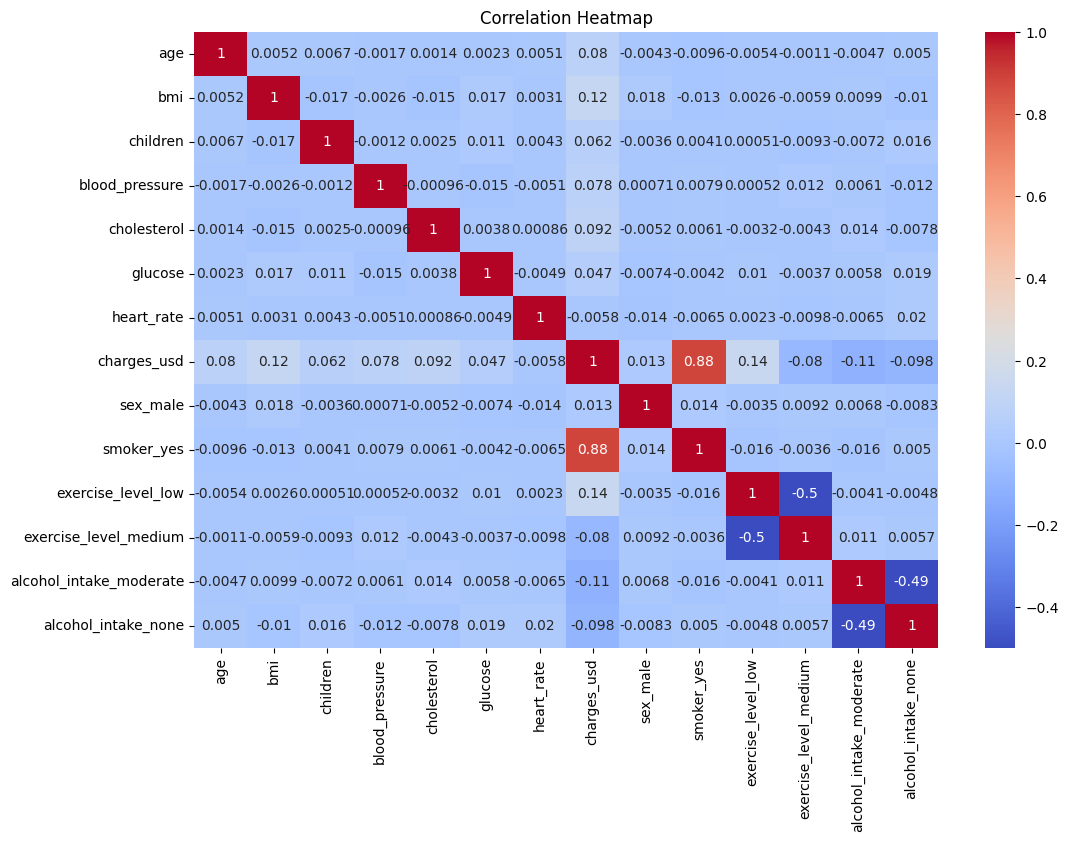

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = dataset.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Features (X) and Target (y)

In [215]:
x = dataset.drop('charges_usd',axis=1)
y = dataset['charges_usd']

Splitting dataset into training and testing sets

In [216]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

Feature Scaling

In [217]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


Model Training and Evaluation Function

In [218]:
def model_evaluate(model):
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print("Training MAE           :", train_mae)
    print("Test MAE               :", test_mae)
    print("Training RMSE          :", train_rmse)
    print("Test RMSE              :", test_rmse)
    print("R² Score (Train)       :", r2_train)
    print("R² Score (Test)        :", r2_test)

    # Cross-validation
    cv_scores = cross_val_score(model, x, y, cv=5, scoring='r2')
    print("Mean CV R² Score       :", cv_scores.mean())
    print("CV R² Scores           :", cv_scores)


Check Models

In [219]:
model = LinearRegression()
model_evaluate(model)

Training MAE           : 2369.0774636366323
Test MAE               : 2421.8723445069763
Training RMSE          : 2956.2877622635724
Test RMSE              : 3048.720139430676
R² Score (Train)       : 0.89071387835423
R² Score (Test)        : 0.8900248051355563
Mean CV R² Score       : 0.8900716605891885
CV R² Scores           : [0.89954464 0.88594177 0.88825425 0.88656445 0.89005319]


In [220]:
model = DecisionTreeRegressor(random_state=42)
model_evaluate(model)

Training MAE           : 0.0
Test MAE               : 3566.3468190000003
Training RMSE          : 0.0
Test RMSE              : 4484.362924474166
R² Score (Train)       : 1.0
R² Score (Test)        : 0.7620634679492602
Mean CV R² Score       : 0.7583448627093115
CV R² Scores           : [0.76930914 0.74386873 0.76485409 0.75479646 0.75889589]


In [221]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
model_evaluate(model)

Training MAE           : 1820.275047374837
Test MAE               : 2517.6547368301667
Training RMSE          : 2274.3405030669815
Test RMSE              : 3164.902719327879
R² Score (Train)       : 0.9353181289744651
R² Score (Test)        : 0.8814830812874992
Mean CV R² Score       : 0.8800594182905979
CV R² Scores           : [0.88968871 0.87593715 0.87819446 0.87654647 0.8799303 ]


In [222]:
model = XGBRegressor(n_estimators =200,random_state=42)
model_evaluate(model)

Training MAE           : 714.4935988067383
Test MAE               : 2694.6418125230466
Training RMSE          : 975.4074265143486
Test RMSE              : 3383.3877766280752
R² Score (Train)       : 0.9881028285969763
R² Score (Test)        : 0.864554939102606
Mean CV R² Score       : 0.8611206199057697
CV R² Scores           : [0.87379166 0.8555246  0.8615664  0.85586699 0.85885345]


Function For Check Models Scores with Charts

In [223]:
def model_evaluation(model, name):
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    r2 = r2_score(y_test, y_test_pred)

    cv_scores = cross_val_score(model, x, y, cv=5, scoring='r2')

    return {
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "R2": r2,
        "CV Mean R2": cv_scores.mean()
    }

In [224]:
#array of results 
results = []

results.append(model_evaluation(LinearRegression(), "Linear Regression"))

results.append(model_evaluation(DecisionTreeRegressor(random_state=42), "Decision Tree"))

results.append(model_evaluation(RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
), "Random Forest"))

results.append(model_evaluation(XGBRegressor(n_estimators=200, random_state=42), "XGBoost"))

In [225]:
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results)

               Model    Train MAE     Test MAE   Train RMSE    Test RMSE  \
0  Linear Regression  2369.077464  2421.872345  2956.287762  3048.720139   
1      Decision Tree     0.000000  3566.346819     0.000000  4484.362924   
2      Random Forest  1820.275047  2517.654737  2274.340503  3164.902719   
3            XGBoost   714.493599  2694.641813   975.407427  3383.387777   

         R2  CV Mean R2  
0  0.890025    0.890072  
1  0.762063    0.758345  
2  0.881483    0.880059  
3  0.864555    0.861121  


Model Comparison Visualization

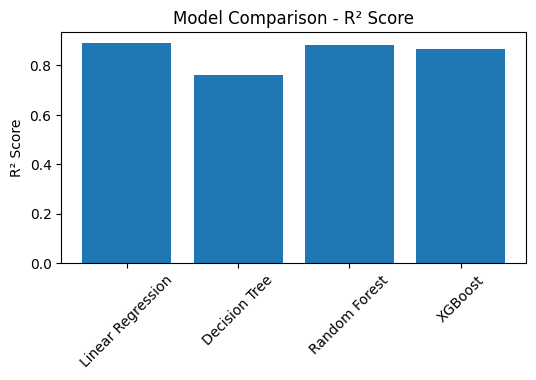

In [226]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.bar(df_results["Model"], df_results["R2"])
plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()

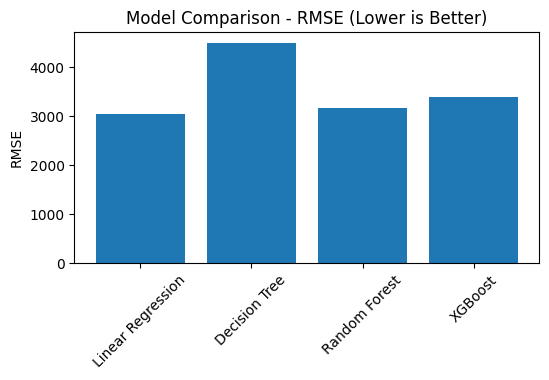

In [227]:
plt.figure(figsize=(6,3))
plt.bar(df_results["Model"], df_results["Test RMSE"])
plt.title("Model Comparison - RMSE (Lower is Better)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

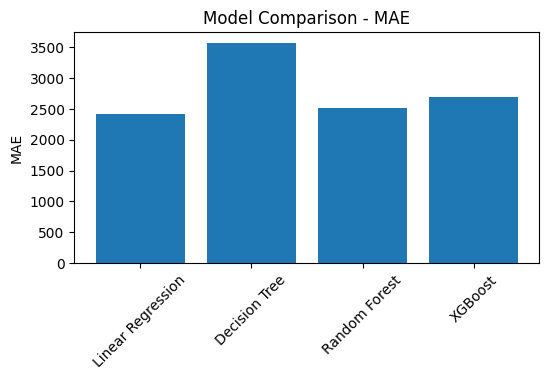

In [228]:
plt.figure(figsize=(6,3))
plt.bar(df_results["Model"], df_results["Test MAE"])
plt.title("Model Comparison - MAE")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

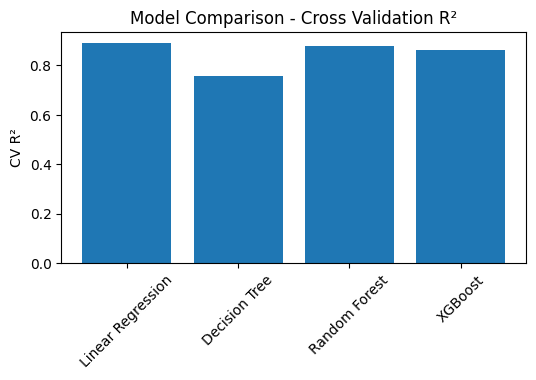

In [229]:
plt.figure(figsize=(6,3))
plt.bar(df_results["Model"], df_results["CV Mean R2"])
plt.title("Model Comparison - Cross Validation R²")
plt.ylabel("CV R²")
plt.xticks(rotation=45)
plt.show()

I choose  model = Linear Regression

 Model Training


In [230]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [231]:
#import pickle

#pickle.dump(model, open("insurance_model.pkl", "wb"))
#pickle.dump(scaler, open("scaler.pkl", "wb"))
#pickle.dump(x.columns, open("columns.pkl", "wb"))

Predict Insurance Cost for New Customer

In [234]:
new_data = {
    "age": 27,
    "bmi": 29,
    "children": 4,
    "blood_pressure": 95,
    "cholesterol": 244,
    "glucose": 92,
    "heart_rate": 69,

    "sex_male": 0,
    "smoker_yes": 0,

    "exercise_level_medium": 0,
    "exercise_level_high": 0,   # low = both 0

    "alcohol_intake_moderate": 0,
    "alcohol_intake_high": 1
}
new_data_df = pd.DataFrame([new_data])

new_data_df = new_data_df.reindex(columns=x.columns, fill_value=0)


new_data_scaled = scaler.transform(new_data_df)

predicted_price = model.predict(new_data_scaled)

print(f"Predicted Cost: ${predicted_price[0]:.2f}")

Predicted Cost: $16346.35
